# Chapter 3

### Example 3.4: Missing Sunday sales

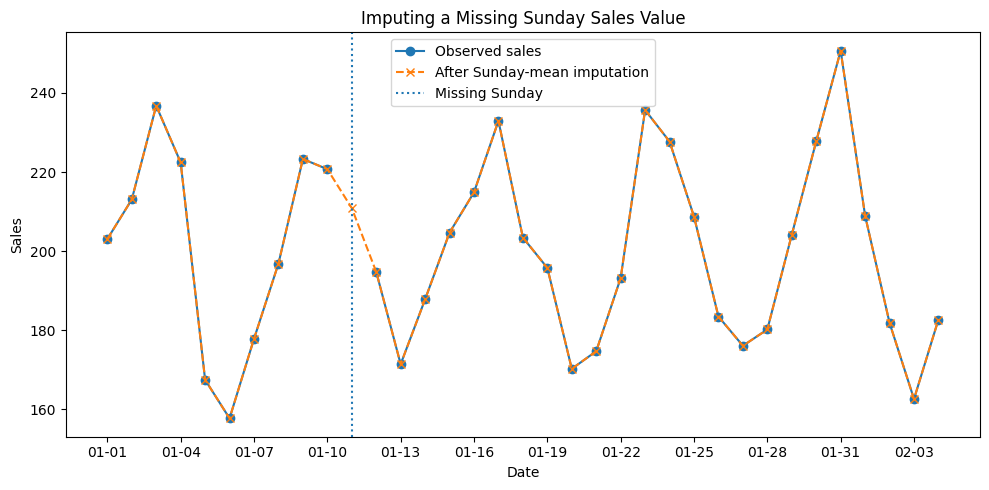

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create example daily sales data
dates = pd.date_range("2026-01-01", periods=35, freq="D")
rng = np.random.default_rng(42)

sales = 200 + 30 * np.sin(np.arange(35) * 2 * np.pi / 7) + rng.normal(0, 10, 35)
df = pd.DataFrame({"date": dates, "sales": sales})

# Create one missing Sunday
missing_date = pd.Timestamp("2026-01-11")
df.loc[df["date"] == missing_date, "sales"] = np.nan

# Impute using average of other Sundays
df["day_name"] = df["date"].dt.day_name()
sunday_mean = df.loc[df["day_name"] == "Sunday", "sales"].mean()
df["sales_imputed"] = df["sales"].fillna(sunday_mean)

# Plot original and imputed data
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["sales"], marker="o", label="Observed sales")
plt.plot(df["date"], df["sales_imputed"], marker="x", linestyle="--", label="After Sunday-mean imputation")
plt.axvline(missing_date, linestyle=":", label="Missing Sunday")
plt.title("Imputing a Missing Sunday Sales Value")
plt.xticks(df["date"][::3], df["date"].dt.strftime("%m-%d")[::3])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

### Example 4.3: Health Diagnostic 

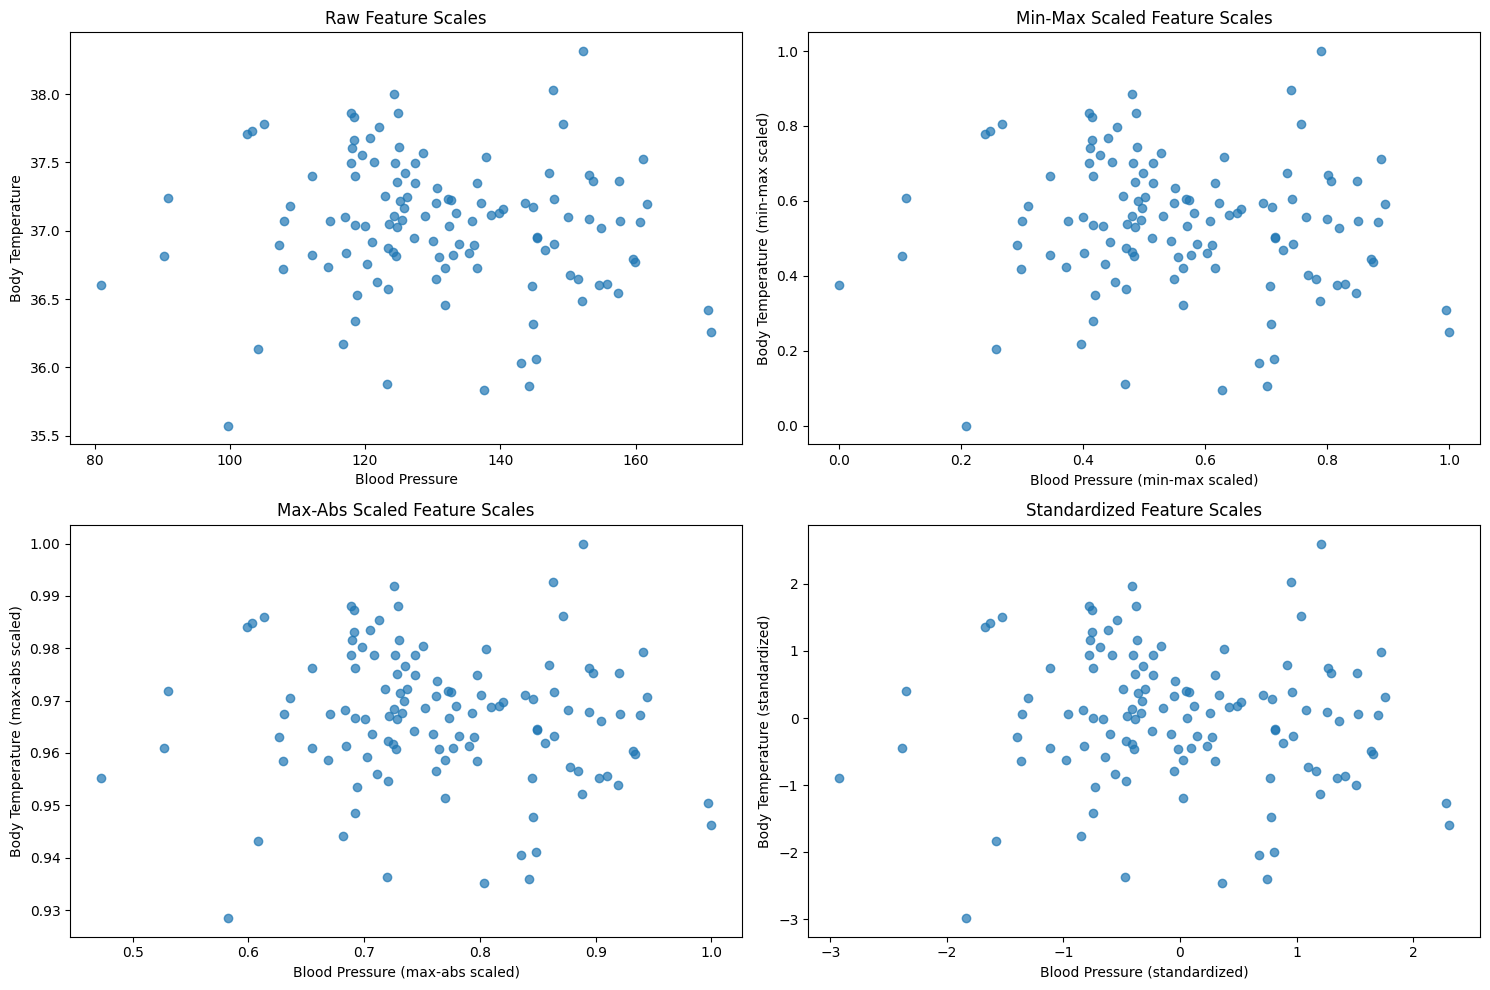

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

rng = np.random.default_rng(123)

# Simulated health data
n = 120
blood_pressure = rng.normal(130, 18, n)
body_temperature = rng.normal(37, 0.5, n)

X = pd.DataFrame({
    "blood_pressure": blood_pressure,
    "body_temperature": body_temperature
})

# Standardize
scaler = StandardScaler()
X_std = pd.DataFrame(
    scaler.fit_transform(X),
    columns=["blood_pressure_scaled", "body_temperature_scaled"]
)

# Min-max scale
min_max_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(
    min_max_scaler.fit_transform(X),
    columns=["blood_pressure_minmax", "body_temperature_minmax"]
)

# Max-abs scale
max_abs_scaler = MaxAbsScaler()
X_maxabs = pd.DataFrame(
    max_abs_scaler.fit_transform(X),
    columns=["blood_pressure_maxabs", "body_temperature_maxabs"]
)

# Put it all together in one plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].scatter(X["blood_pressure"], X["body_temperature"], alpha=0.7)
axes[0, 0].set_title("Raw Feature Scales")
axes[0, 0].set_xlabel("Blood Pressure")
axes[0, 0].set_ylabel("Body Temperature")  
axes[0, 1].scatter(X_minmax["blood_pressure_minmax"], X_minmax["body_temperature_minmax"], alpha=0.7)
axes[0, 1].set_title("Min-Max Scaled Feature Scales")
axes[0, 1].set_xlabel("Blood Pressure (min-max scaled)")
axes[0, 1].set_ylabel("Body Temperature (min-max scaled)")
axes[1, 0].scatter(X_maxabs["blood_pressure_maxabs"], X_maxabs["body_temperature_maxabs"], alpha=0.7)
axes[1, 0].set_title("Max-Abs Scaled Feature Scales")
axes[1, 0].set_xlabel("Blood Pressure (max-abs scaled)")
axes[1, 0].set_ylabel("Body Temperature (max-abs scaled)")
axes[1, 1].scatter(X_std["blood_pressure_scaled"], X_std["body_temperature_scaled"], alpha=0.7)
axes[1, 1].set_title("Standardized Feature Scales")
axes[1, 1].set_xlabel("Blood Pressure (standardized)")
axes[1, 1].set_ylabel("Body Temperature (standardized)")
plt.tight_layout()
plt.show()

### Example 5.2: Movie Encoding

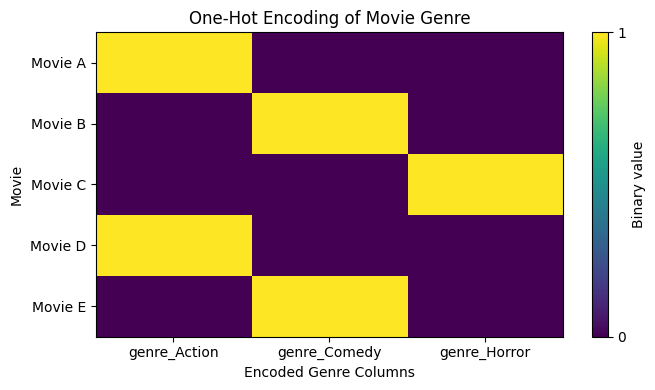

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

movies = pd.DataFrame({
    "movie": ["Movie A", "Movie B", "Movie C", "Movie D", "Movie E"],
    "genre": ["Action", "Comedy", "Horror", "Action", "Comedy"]
})

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(movies[["genre"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["genre"])
)

plot_df = encoded_df.copy()
plot_df.index = movies["movie"]

plt.figure(figsize=(7, 4))
plt.imshow(plot_df, aspect="auto")
plt.title("One-Hot Encoding of Movie Genre")
plt.xlabel("Encoded Genre Columns")
plt.ylabel("Movie")
plt.xticks(range(len(plot_df.columns)), plot_df.columns)
plt.yticks(range(len(plot_df.index)), plot_df.index)
plt.colorbar(label="Binary value")
# set color bar ticks to 0 and 1
cbar = plt.gcf().axes[-1]
cbar.set_yticks([0, 1])
plt.tight_layout()
plt.show()

### Example 6: Email Spam Classification

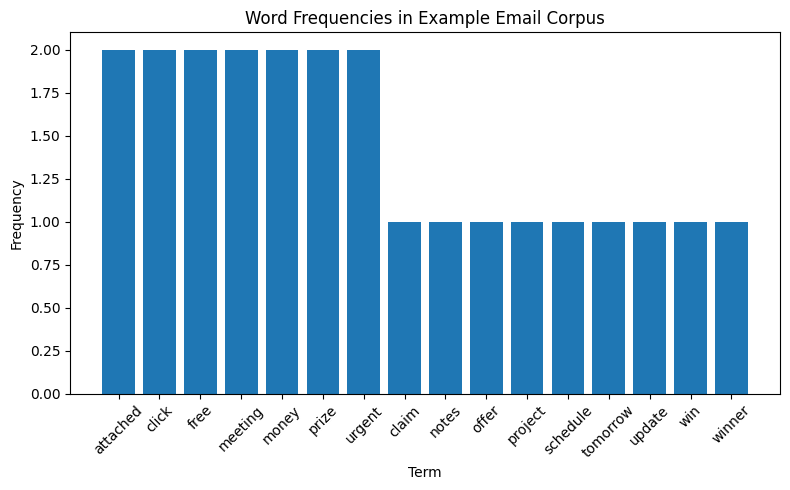

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

emails = [
    "Win money now click urgent prize",
    "Meeting schedule attached for tomorrow",
    "Urgent winner claim your free prize now",
    "Project update and meeting notes attached",
    "Free money offer click now"
]

labels = ["spam", "not spam", "spam", "not spam", "spam"]

vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(emails)

word_counts = X.toarray().sum(axis=0)
terms = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "term": terms,
    "count": word_counts
}).sort_values("count", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(freq_df["term"], freq_df["count"])
plt.title("Word Frequencies in Example Email Corpus")
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Example: Image Augmentation

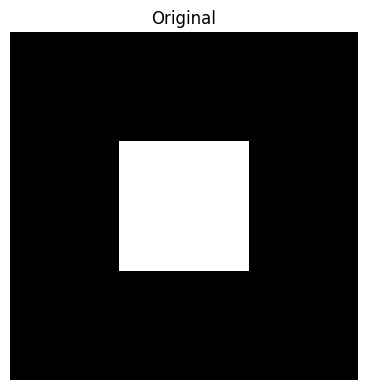

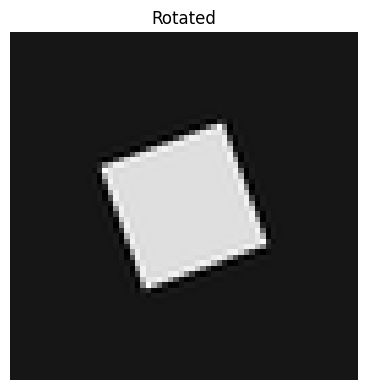

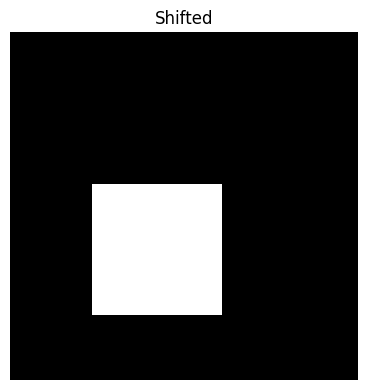

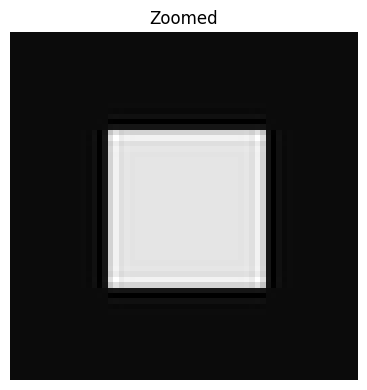

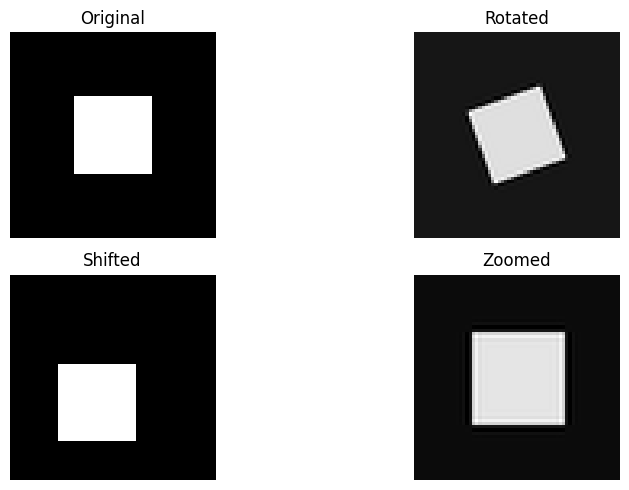

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate, shift, zoom

# Create a simple synthetic image: a bright square on a dark background
img = np.zeros((64, 64))
img[20:44, 20:44] = 1.0

# Create augmentations
rotated = rotate(img, angle=20, reshape=False)
shifted = shift(img, shift=(8, -5))
zoomed = zoom(img, zoom=1.2)

# Crop zoomed image back to 64x64
start = (zoomed.shape[0] - 64) // 2
zoomed_crop = zoomed[start:start+64, start:start+64]

images = [img, rotated, shifted, zoomed_crop]
titles = ["Original", "Rotated", "Shifted", "Zoomed"]

for image, title in zip(images, titles):
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# put all images in one plot
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
for ax, image, title in zip(axes.flatten(), images, titles):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

#### Example: Overfitting

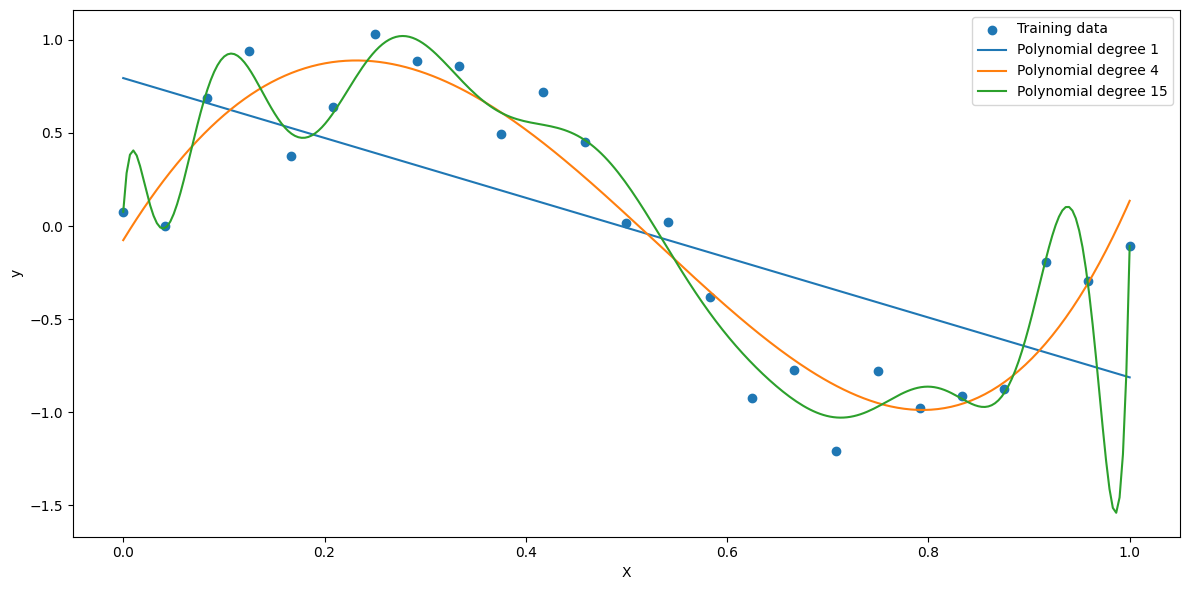

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(42)

# Synthetic nonlinear data
X = np.linspace(0, 1, 25).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + rng.normal(0, 0.25, X.shape[0])

X_grid = np.linspace(0, 1, 300).reshape(-1, 1)

degrees = [1, 4, 15]

plt.figure(figsize=(12, 6))
plt.scatter(X, y, label="Training data")
for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])
    model.fit(X, y)
    y_pred = model.predict(X_grid)
    plt.plot(X_grid, y_pred, label=f"Polynomial degree {degree}")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

### Ex: Cross Validation

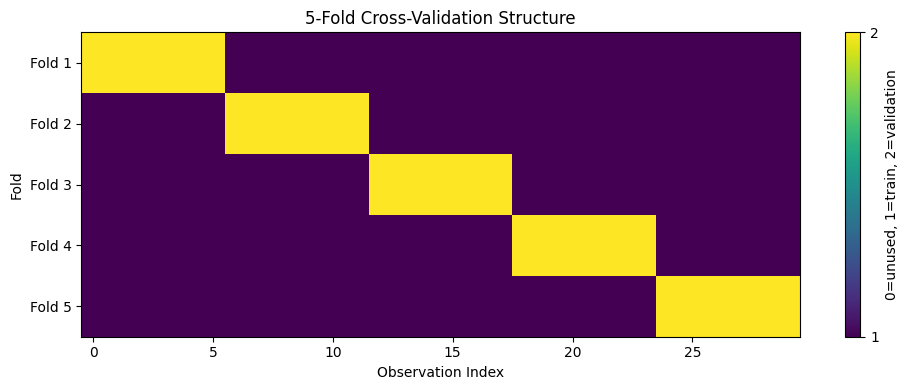

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

n_samples = 30
k = 5

X = np.arange(n_samples)
kf = KFold(n_splits=k, shuffle=False)

fold_matrix = np.zeros((k, n_samples))

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    fold_matrix[fold_idx, train_idx] = 1
    fold_matrix[fold_idx, val_idx] = 2

plt.figure(figsize=(10, 4))
plt.imshow(fold_matrix, aspect="auto")
plt.title("5-Fold Cross-Validation Structure")
plt.xlabel("Observation Index")
plt.ylabel("Fold")
plt.yticks(range(k), [f"Fold {i+1}" for i in range(k)])
plt.colorbar(ticks=[0, 1, 2], label="0=unused, 1=train, 2=validation")
plt.tight_layout()
plt.show()

### Hyperparameter search

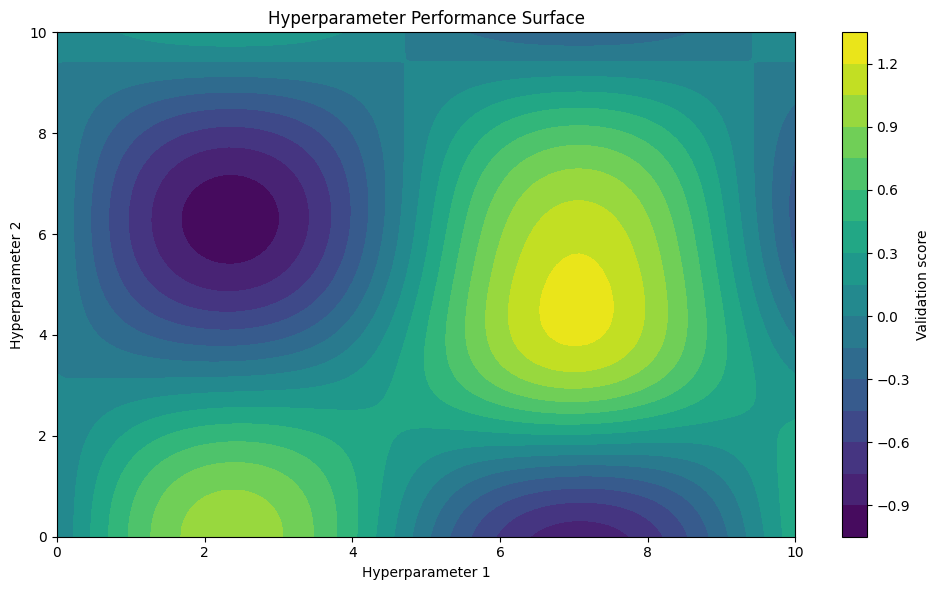

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic validation performance surface
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x, y)

Z = np.sin(X / 1.5) * np.cos(Y / 2) + np.exp(-((X - 7)**2 + (Y - 3)**2) / 5)

plt.figure(figsize=(10, 6))
contour = plt.contourf(X, Y, Z, levels=20)
plt.title("Hyperparameter Performance Surface")
plt.xlabel("Hyperparameter 1")
plt.ylabel("Hyperparameter 2")
plt.colorbar(contour, label="Validation score")
plt.tight_layout()
plt.show()

### Pipeline

In [39]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Example dataset
df = pd.DataFrame({
    "age": [22, 35, 41, None, 58, 29],
    "income": [45000, 62000, None, 52000, 88000, 39000],
    "genre_preference": ["Action", "Comedy", "Horror", "Action", None, "Comedy"],
    "purchased": [0, 1, 1, 0, 1, 0]
})

X = df.drop(columns=["purchased"])
y = df["purchased"]

numeric_features = ["age", "income"]
categorical_features = ["genre_preference"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

model_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

model_pipeline.fit(X_train, y_train)
test_score = model_pipeline.score(X_test, y_test)

print("Test score:", test_score)

Test score: 0.5


### Gaussian Process

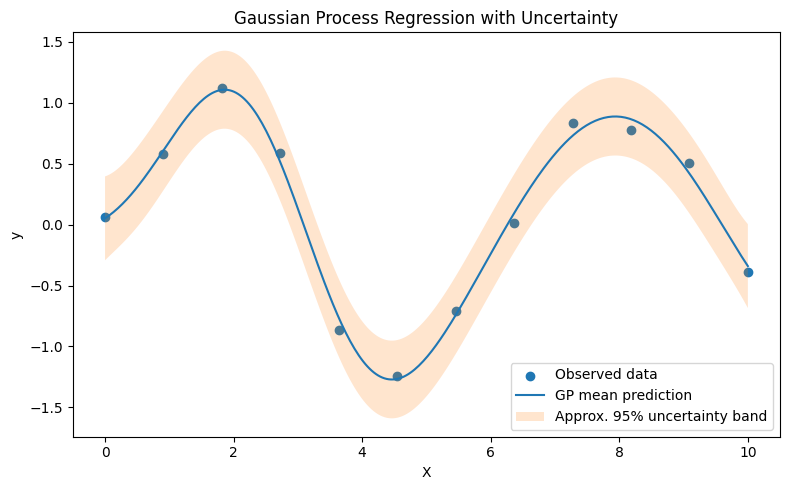

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

rng = np.random.default_rng(42)

# Training data
X_train = np.linspace(0, 10, 12).reshape(-1, 1)
y_train = np.sin(X_train).ravel() + rng.normal(0, 0.2, X_train.shape[0])

# Test grid
X_grid = np.linspace(0, 10, 300).reshape(-1, 1)

# GP model
kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
gp = GaussianProcessRegressor(kernel=kernel, random_state=42)
gp.fit(X_train, y_train)

y_mean, y_std = gp.predict(X_grid, return_std=True)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Observed data")
plt.plot(X_grid, y_mean, label="GP mean prediction")
plt.fill_between(
    X_grid.ravel(),
    y_mean - 2 * y_std,
    y_mean + 2 * y_std,
    alpha=0.2,
    label="Approx. 95% uncertainty band"
)
plt.title("Gaussian Process Regression with Uncertainty")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

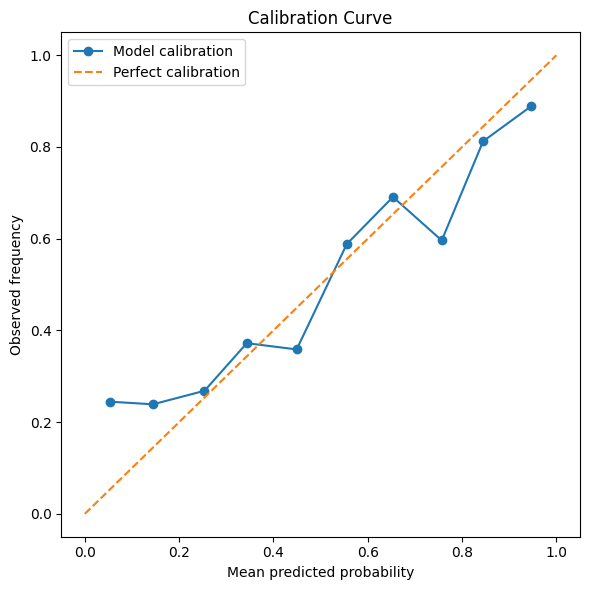

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

rng = np.random.default_rng(42)

# Simulated predicted probabilities and outcomes
y_prob = rng.uniform(0, 1, 500)
true_prob = 0.8 * y_prob + 0.1
y_true = rng.binomial(1, true_prob)

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model calibration")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Curve")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.legend()
plt.tight_layout()
plt.show()